# Text Generation with GPT

In this notebook, we explore **decoder-only transformer models** like GPT (Generative Pre-trained Transformer) for text generation. We'll understand how autoregressive generation works, experiment with different sampling strategies, and learn how to measure generation quality with quantitative metrics.

## Learning Objectives

1. Understand the difference between encoder (BERT) and decoder (GPT) architectures
2. Learn autoregressive text generation
3. Experiment with sampling strategies (temperature, top-k, top-p)
4. Measure generation quality with metrics (perplexity, diversity, BLEU, ROUGE)
5. Understand when to use GPT vs BERT

---

## 1. Introduction: Decoder Architecture

### BERT vs GPT: Key Differences

| Feature | BERT (Encoder) | GPT (Decoder) |
|---------|----------------|---------------|
| **Architecture** | Bidirectional | Unidirectional (causal) |
| **Attention** | Can see all tokens | Can only see previous tokens |
| **Training Task** | Masked Language Modeling (MLM) | Next Token Prediction |
| **Best For** | Understanding, Classification, Q&A | Generation, Completion, Few-shot |
| **Cannot Do** | Generate fluent text | Extract spans efficiently |

### Autoregressive Generation

GPT generates text **one token at a time**, always predicting the next token based on all previous tokens:

```
Input:  "The cat sat on the"
Step 1: Predict next token → "mat" (probability distribution over vocab)
Step 2: Append "mat" → "The cat sat on the mat"
Step 3: Predict next token → "."
Step 4: Continue until <EOS> or max_length
```

This is called **autoregressive** because each prediction depends on previous predictions.

---
## 2. Setup & Dependencies

In [1]:
# Install required packages
!pip install -q transformers datasets evaluate torch torchmetrics sacrebleu rouge-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.0 MB/s eta 0:00:00


In [2]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer, set_seed
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
from typing import List, Dict
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
set_seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Load GPT-2 Model and Tokenizer

We'll use GPT-2 (small) which has 124M parameters. It's fast enough for demonstration while still producing quality results.

In [3]:
# Load pre-trained GPT-2 model and tokenizer
model_name = 'gpt2'  # GPT-2 small (124M parameters)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name).to(device)

# Set padding token (GPT-2 doesn't have one by default)
tokenizer.pad_token = tokenizer.eos_token

print(f"Model: {model_name}")
print(f"Vocabulary size: {len(tokenizer)}")
print(f"Model parameters: {model.num_parameters():,}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: gpt2
Vocabulary size: 50257
Model parameters: 124,439,808


---
## 3. Basic Text Generation

Let's start with a simple example to understand how GPT generates text.

In [4]:
# Define a prompt
prompt = "Artificial intelligence is"

# Tokenize
input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

print(f"Prompt: '{prompt}'")
print(f"Input tokens: {input_ids}")
print(f"Token IDs: {input_ids.tolist()[0]}")
print(f"Decoded tokens: {[tokenizer.decode([tid]) for tid in input_ids[0]]}")

Prompt: 'Artificial intelligence is'
Input tokens: tensor([[8001, 9542, 4430,  318]])
Token IDs: [8001, 9542, 4430, 318]
Decoded tokens: ['Art', 'ificial', ' intelligence', ' is']


### Greedy Decoding (Argmax)

The simplest generation strategy: always pick the most probable next token.

In [5]:
# Generate using greedy decoding
output_greedy = model.generate(
    input_ids,
    max_length=50,
    num_return_sequences=1,
    pad_token_id=tokenizer.eos_token_id,
    do_sample=False  # Greedy (deterministic)
)

generated_text = tokenizer.decode(output_greedy[0], skip_special_tokens=True)
print("\n=== Greedy Decoding ===")
print(generated_text)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



=== Greedy Decoding ===
Artificial intelligence is a new field of research that has been in the works for a while now. It is a field that has been in the works for a while now. It is a field that has been in the works for a while now.


**Problem with greedy decoding:** Let's generate multiple times and see if we get variety...

In [6]:
# Generate 3 times with greedy
print("Generating 3 times with greedy decoding:\n")
for i in range(3):
    output = model.generate(
        input_ids,
        max_length=30,
        do_sample=False
    )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"{i+1}. {text}\n")

print("❌ All identical! Greedy is deterministic and repetitive.")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating 3 times with greedy decoding:



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


1. Artificial intelligence is a new field of research that has been in the works for a while now. It is a field that has been in the works



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


2. Artificial intelligence is a new field of research that has been in the works for a while now. It is a field that has been in the works

3. Artificial intelligence is a new field of research that has been in the works for a while now. It is a field that has been in the works

❌ All identical! Greedy is deterministic and repetitive.


---
## 4. Sampling Strategies

To get diverse and creative outputs, we need **sampling** instead of always picking the argmax.

### 4.1 Temperature Sampling

Temperature controls randomness by scaling logits before softmax:

$$
P(w_i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}
$$

- **T → 0**: Approaches greedy (picks highest probability)
- **T = 1**: Normal probabilities
- **T > 1**: More random (flatter distribution)

In [7]:
# Test different temperatures
temperatures = [0.3, 0.7, 1.0, 1.5, 2.0]

print(f"Prompt: '{prompt}'\n")
print("="*80)

for temp in temperatures:
    output = model.generate(
        input_ids,
        max_length=40,
        do_sample=True,
        temperature=temp,
        num_return_sequences=1
    )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"Temperature {temp}:")
    print(f"  {text}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: 'Artificial intelligence is'



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Temperature 0.3:
  Artificial intelligence is a new field of research that is being pursued by many different fields. The goal of this article is to provide a brief overview of the current state of artificial intelligence research and to provide



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Temperature 0.7:
  Artificial intelligence is just one of the many ways that we will be able to use technology to improve our lives. It can be used to improve our health and wellbeing, to improve our lives through education



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Temperature 1.0:
  Artificial intelligence is probably best used today. It can't tell the difference between two entities, nor what other information is being generated from the two entities. It can't tell about the origin of a



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Temperature 1.5:
  Artificial intelligence is going mainstream with a lot of success now, is this truly it? Or was it not supposed to be such a good bet (like it is) or did it manage to out

Temperature 2.0:
  Artificial intelligence is developing to improve performance on tasks at work in virtual and physical lab work, study finds More automation is on the way, to get planned these studies, researchers at Georgia Agricultural University said



**Observations:**
- Low temperature (0.3): Conservative, coherent, but boring
- Medium temperature (0.7-1.0): Good balance of coherence and creativity
- High temperature (1.5+): Very creative but can become incoherent

### 4.2 Top-k Sampling

Only sample from the **k most likely tokens** at each step. This prevents sampling very unlikely (nonsensical) words.

In [8]:
# Test different top-k values
top_k_values = [10, 50, 100, 500]

print(f"Prompt: '{prompt}'\n")
print("="*80)

for k in top_k_values:
    output = model.generate(
        input_ids,
        max_length=40,
        do_sample=True,
        top_k=k,
        temperature=1.0,
        num_return_sequences=1
    )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"Top-k={k}:")
    print(f"  {text}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: 'Artificial intelligence is'



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Top-k=10:
  Artificial intelligence is not a new concept in science fiction and science-fiction. A lot of the technologies that were developed at the University of California at Riverside were actually developed in the late 1980s and



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Top-k=50:
  Artificial intelligence is now able to handle many types of information at once. In fact, it already does, based on the fact that our entire brains have a single output that has more than the sum



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Top-k=100:
  Artificial intelligence is going global and it's going to come roaring back,'' he said. ''And I think that's why we need the technology to drive the innovation that you've seen develop so far

Top-k=500:
  Artificial intelligence is one of those newer developments. The technology, although still only a few years away in a country where AI has not done that for decades, seems less about numbers and more about our



### 4.3 Top-p (Nucleus) Sampling

Sample from the **smallest set of tokens whose cumulative probability ≥ p**.

- More dynamic than top-k (adapts vocabulary size)
- p=0.9 is a common default

In [9]:
# Test different top-p values
top_p_values = [0.5, 0.7, 0.9, 0.95, 1.0]

print(f"Prompt: '{prompt}'\n")
print("="*80)

for p in top_p_values:
    output = model.generate(
        input_ids,
        max_length=40,
        do_sample=True,
        top_p=p,
        temperature=1.0,
        num_return_sequences=1
    )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"Top-p={p}:")
    print(f"  {text}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: 'Artificial intelligence is'



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Top-p=0.5:
  Artificial intelligence is also an emerging field.

The AI revolution has led to the emergence of the AI market.

The first step towards a real-world market is to develop the AI



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Top-p=0.7:
  Artificial intelligence is one of the most advanced tools ever developed to develop new technologies. It has enabled the development of intelligent, personalized services such as artificial intelligence and AI. This has allowed the development of



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Top-p=0.9:
  Artificial intelligence is also one of the most promising developments in its field, with advancements such as artificial neural networks, artificial neural networks, and artificial neural networks (AI). AI is becoming more important as



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Top-p=0.95:
  Artificial intelligence is getting smarter.

"We don't even know if it's going to get any better or better for me," said Paul F. Chiappucci, a professor at

Top-p=1.0:
  Artificial intelligence is, as they say, the new wave of tech. But until these things come, they won't be in our favor, as tech continues to take over the world.



### 4.4 Combined Strategy (Temperature + Top-p)

In practice, we often combine temperature with top-p for best results.

In [10]:
# Generate with combined strategy (common in production)
output = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    num_return_sequences=5  # Generate multiple samples
)

print(f"Prompt: '{prompt}'\n")
print("5 samples with temperature=0.8, top_p=0.9:\n")
print("="*80)

for i, output_seq in enumerate(output, 1):
    text = tokenizer.decode(output_seq, skip_special_tokens=True)
    print(f"{i}. {text}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: 'Artificial intelligence is'

5 samples with temperature=0.8, top_p=0.9:

1. Artificial intelligence is not yet a reality, but its potential will make it even more interesting.

In the future, artificial intelligence will be an important part of everyday life, as it will help us navigate difficult situations. But we have no idea

2. Artificial intelligence is one of the best ways to reduce the cost of living, and that is why we are seeing a great increase in the amount of people who are able to live in cities and in rural areas. The cost of living in the United

3. Artificial intelligence is very complex, but it can be very useful in this area. You can get a lot of good results with it, but if you want to make it very useful for specific tasks, you need to know how it works. It

4. Artificial intelligence is a major threat to the American economy. The National Science Foundation is among the nation's leading research organizations devoted to advancing artificial intelligence re

---
## 5. Generation Metrics

Now that we can generate text, how do we **measure quality** quantitatively?

We'll cover:
1. **Perplexity** - Model confidence
2. **Diversity metrics** - Uniqueness of outputs
3. **BLEU** - For comparison tasks (translation, paraphrasing)
4. **ROUGE** - For summarization tasks
5. **Human evaluation criteria** - Framework for subjective assessment

### 5.1 Perplexity

**Perplexity** measures how "surprised" the model is by text:

$$
\text{Perplexity} = e^{-\frac{1}{N} \sum_{i=1}^{N} \log P(w_i | w_{<i})}
$$

- **Lower perplexity** = more confident = better language model
- Typical values: 20-50 for good models on test data

In [11]:
def calculate_perplexity(model, tokenizer, text, device):
    """
    Calculate perplexity of a text under the model.
    """
    encodings = tokenizer(text, return_tensors='pt')
    input_ids = encodings.input_ids.to(device)

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss
        perplexity = torch.exp(loss)

    return perplexity.item()

# Test on sample texts
test_texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Machine learning is a subset of artificial intelligence.",
    "Colorless green ideas sleep furiously.",  # Grammatical but nonsensical
    "asdf qwer zxcv uiop"  # Random characters
]

print("Perplexity Comparison:\n")
perplexity_results = []
for text in test_texts:
    ppl = calculate_perplexity(model, tokenizer, text, device)
    perplexity_results.append({'text': text[:50], 'perplexity': ppl})
    print(f"Text: {text}")
    print(f"Perplexity: {ppl:.2f}\n")

print("✅ Lower perplexity = model is more confident about the text")

Perplexity Comparison:



`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Text: The quick brown fox jumps over the lazy dog.
Perplexity: 162.47

Text: Machine learning is a subset of artificial intelligence.
Perplexity: 25.57

Text: Colorless green ideas sleep furiously.
Perplexity: 6413.31

Text: asdf qwer zxcv uiop
Perplexity: 3184.83

✅ Lower perplexity = model is more confident about the text


### 5.2 Diversity Metrics

Diversity measures how unique/varied the generated texts are:

1. **Distinct-n**: Percentage of unique n-grams
   - Distinct-1: unique unigrams / total unigrams
   - Distinct-2: unique bigrams / total bigrams
   
2. **Self-BLEU**: Average BLEU score between generated samples (lower = more diverse)

In [12]:
def calculate_distinct_n(texts: List[str], n: int) -> float:
    """
    Calculate Distinct-n: ratio of unique n-grams to total n-grams.
    Higher = more diverse.
    """
    all_ngrams = []
    for text in texts:
        tokens = text.lower().split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        all_ngrams.extend(ngrams)

    if len(all_ngrams) == 0:
        return 0.0

    unique_ngrams = len(set(all_ngrams))
    total_ngrams = len(all_ngrams)

    return unique_ngrams / total_ngrams

def calculate_self_bleu(texts: List[str]) -> float:
    """
    Calculate Self-BLEU: average BLEU score when each text is compared
    against all others. Lower = more diverse.
    """
    from evaluate import load
    bleu = load('bleu')

    scores = []
    for i, text in enumerate(texts):
        others = [texts[j] for j in range(len(texts)) if j != i]
        if len(others) > 0:
            result = bleu.compute(predictions=[text], references=[others])
            scores.append(result['bleu'])

    return np.mean(scores) if scores else 0.0

In [13]:
# Compare diversity across different temperatures
prompt = "In the future, artificial intelligence will"
input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

temperatures_to_test = [0.3, 0.7, 1.0, 1.5]
num_samples = 20

diversity_results = []

print("Generating samples for diversity analysis...\n")

for temp in temperatures_to_test:
    # Generate multiple samples
    outputs = model.generate(
        input_ids,
        max_length=30,
        do_sample=True,
        temperature=temp,
        num_return_sequences=num_samples
    )

    texts = [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]

    # Calculate metrics
    distinct_1 = calculate_distinct_n(texts, 1)
    distinct_2 = calculate_distinct_n(texts, 2)
    distinct_3 = calculate_distinct_n(texts, 3)
    avg_length = np.mean([len(text.split()) for text in texts])

    diversity_results.append({
        'temperature': temp,
        'distinct_1': distinct_1,
        'distinct_2': distinct_2,
        'distinct_3': distinct_3,
        'avg_length': avg_length
    })

    print(f"Temperature {temp}:")
    print(f"  Distinct-1: {distinct_1:.3f}")
    print(f"  Distinct-2: {distinct_2:.3f}")
    print(f"  Distinct-3: {distinct_3:.3f}")
    print(f"  Avg Length: {avg_length:.1f} words\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating samples for diversity analysis...



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Temperature 0.3:
  Distinct-1: 0.250
  Distinct-2: 0.428
  Distinct-3: 0.512
  Avg Length: 25.6 words



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Temperature 0.7:
  Distinct-1: 0.363
  Distinct-2: 0.627
  Distinct-3: 0.717
  Avg Length: 25.5 words



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Temperature 1.0:
  Distinct-1: 0.417
  Distinct-2: 0.690
  Distinct-3: 0.758
  Avg Length: 26.1 words

Temperature 1.5:
  Distinct-1: 0.492
  Distinct-2: 0.784
  Distinct-3: 0.832
  Avg Length: 26.6 words



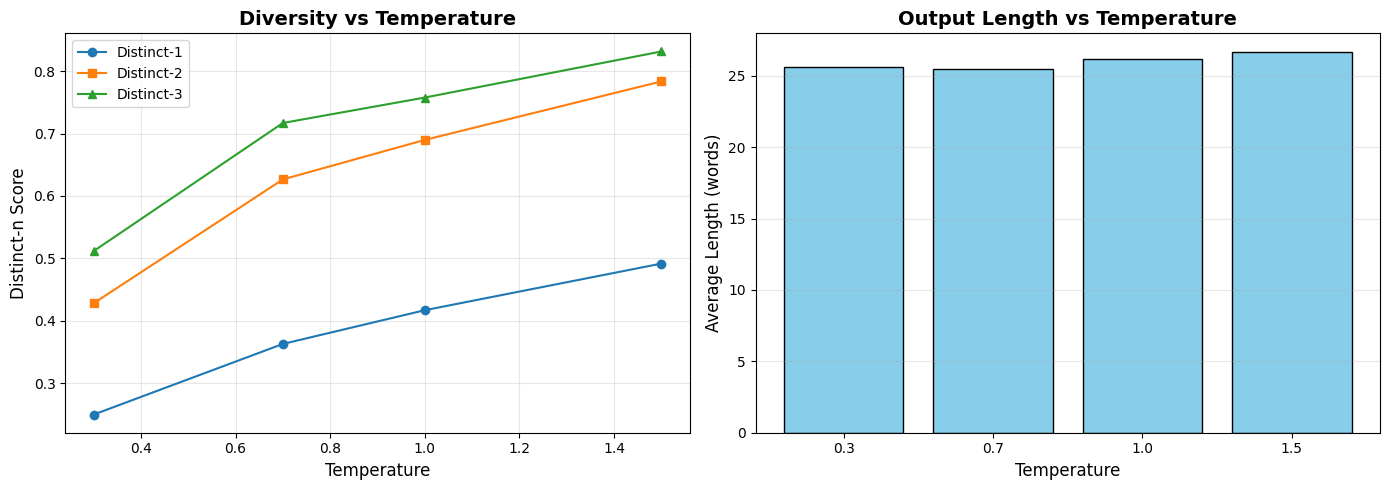


✅ Higher temperature → more diverse outputs (higher Distinct-n)


In [14]:
# Visualize diversity vs temperature
df_diversity = pd.DataFrame(diversity_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distinct-n metrics
axes[0].plot(df_diversity['temperature'], df_diversity['distinct_1'], marker='o', label='Distinct-1')
axes[0].plot(df_diversity['temperature'], df_diversity['distinct_2'], marker='s', label='Distinct-2')
axes[0].plot(df_diversity['temperature'], df_diversity['distinct_3'], marker='^', label='Distinct-3')
axes[0].set_xlabel('Temperature', fontsize=12)
axes[0].set_ylabel('Distinct-n Score', fontsize=12)
axes[0].set_title('Diversity vs Temperature', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Average length
axes[1].bar(df_diversity['temperature'].astype(str), df_diversity['avg_length'], color='skyblue', edgecolor='black')
axes[1].set_xlabel('Temperature', fontsize=12)
axes[1].set_ylabel('Average Length (words)', fontsize=12)
axes[1].set_title('Output Length vs Temperature', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Higher temperature → more diverse outputs (higher Distinct-n)")

### 5.3 BLEU Score (for Comparison Tasks)

**BLEU** (Bilingual Evaluation Understudy) measures n-gram overlap between generated and reference texts.

- Used for: translation, paraphrasing, any task with reference outputs
- Range: 0-1 (or 0-100), higher is better
- Limitation: doesn't capture semantic similarity well

In [15]:
from evaluate import load

bleu = load('bleu')

# Example: paraphrasing task
original = "The cat sat on the mat."
references = [
    "A cat was sitting on a mat.",
    "The feline rested on the rug."
]

# Simulate GPT paraphrasing (in practice, you'd generate this)
predictions = [
    "The cat was sitting on the mat.",
    "A dog sat on the floor.",
    "Cats enjoy sitting on mats."
]

print("BLEU Score Examples:\n")
for pred in predictions:
    result = bleu.compute(predictions=[pred], references=[references])
    print(f"Prediction: {pred}")
    print(f"BLEU: {result['bleu']:.4f}\n")

BLEU Score Examples:

Prediction: The cat was sitting on the mat.
BLEU: 0.4671

Prediction: A dog sat on the floor.
BLEU: 0.0000

Prediction: Cats enjoy sitting on mats.
BLEU: 0.0000



### 5.4 ROUGE Score (for Summarization)

**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) measures recall of n-grams.

- Used for: summarization, content selection
- Variants: ROUGE-1 (unigrams), ROUGE-2 (bigrams), ROUGE-L (longest common subsequence)

In [16]:
rouge = load('rouge')

# Example: summarization task
document = """Artificial intelligence (AI) is intelligence demonstrated by machines,
in contrast to the natural intelligence displayed by humans and animals. Leading AI
textbooks define the field as the study of intelligent agents: any device that perceives
its environment and takes actions that maximize its chance of successfully achieving its goals."""

reference_summary = "AI is intelligence shown by machines, contrasting with natural intelligence."

# Simulated summaries (in practice, GPT would generate these)
generated_summaries = [
    "AI is machine intelligence, different from human and animal intelligence.",
    "Artificial intelligence involves intelligent agents that perceive and act.",
    "The weather is nice today."
]

print("ROUGE Score Examples:\n")
for summary in generated_summaries:
    result = rouge.compute(predictions=[summary], references=[reference_summary])
    print(f"Summary: {summary}")
    print(f"ROUGE-1: {result['rouge1']:.4f}")
    print(f"ROUGE-2: {result['rouge2']:.4f}")
    print(f"ROUGE-L: {result['rougeL']:.4f}\n")

ROUGE Score Examples:

Summary: AI is machine intelligence, different from human and animal intelligence.
ROUGE-1: 0.4000
ROUGE-2: 0.1111
ROUGE-L: 0.4000

Summary: Artificial intelligence involves intelligent agents that perceive and act.
ROUGE-1: 0.1053
ROUGE-2: 0.0000
ROUGE-L: 0.1053

Summary: The weather is nice today.
ROUGE-1: 0.1333
ROUGE-2: 0.0000
ROUGE-L: 0.1333



### 5.5 Human Evaluation Framework

Automatic metrics don't capture everything. For production systems, human evaluation is crucial.

**Common criteria (1-5 scale):**

1. **Fluency**: Is the text grammatically correct and natural?
2. **Coherence**: Does the text make logical sense?
3. **Relevance**: Does the text address the prompt/task?
4. **Informativeness**: Does the text provide useful information?
5. **Creativity**: Is the text original and interesting? (for creative tasks)

**Example evaluation:**

In [17]:
# Example human evaluation template
evaluation_examples = [
    {
        'prompt': 'Write about AI ethics',
        'generation': 'AI ethics involves considering fairness, accountability, transparency, and the societal impact of artificial intelligence systems.',
        'fluency': 5,
        'coherence': 5,
        'relevance': 5,
        'informativeness': 4
    },
    {
        'prompt': 'Write about AI ethics',
        'generation': 'The blue sky is very beautiful and cats like to play with yarn.',
        'fluency': 5,
        'coherence': 3,
        'relevance': 1,
        'informativeness': 1
    }
]

df_eval = pd.DataFrame(evaluation_examples)
df_eval['avg_score'] = df_eval[['fluency', 'coherence', 'relevance', 'informativeness']].mean(axis=1)

print("Human Evaluation Example:")
print(df_eval[['generation', 'fluency', 'coherence', 'relevance', 'informativeness', 'avg_score']].to_string(index=False))
print("\n✅ In production, collect ratings from multiple human evaluators")

Human Evaluation Example:
                                                                                                                        generation  fluency  coherence  relevance  informativeness  avg_score
AI ethics involves considering fairness, accountability, transparency, and the societal impact of artificial intelligence systems.        5          5          5                4       4.75
                                                                   The blue sky is very beautiful and cats like to play with yarn.        5          3          1                1       2.50

✅ In production, collect ratings from multiple human evaluators


---
## 6. Controlled Generation

In practice, we want more control over generated text.

### 6.1 Prompt Engineering

The prompt dramatically affects output quality.

In [18]:
# Zero-shot vs Few-shot prompts
prompts = [
    # Zero-shot
    "Translate to French: Hello, how are you?",

    # Few-shot (with examples)
    """Translate to French:
English: Good morning.
French: Bonjour.

English: Thank you.
French: Merci.

English: Hello, how are you?
French:"""
]

print("Comparing Zero-shot vs Few-shot:\n")
print("="*80)

for i, prompt in enumerate(prompts, 1):
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    output = model.generate(
        input_ids,
        max_length=input_ids.shape[1] + 20,
        temperature=0.7,
        do_sample=True
    )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"Prompt {i}: {'Zero-shot' if i == 1 else 'Few-shot'}")
    print(f"{text}\n")
    print("="*80)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Comparing Zero-shot vs Few-shot:



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt 1: Zero-shot
Translate to French: Hello, how are you?

: Hello, how are you? [F4M][Script Offer] [The girl

Prompt 2: Few-shot
Translate to French:
English: Good morning.
French: Bonjour.

English: Thank you.
French: Merci.

English: Hello, how are you?
French: I'm fine.

French: Let's go.

French: What are you doing



### 6.2 Length Control & Repetition Penalty

In [19]:
prompt = "Machine learning is"
input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

# Test repetition penalty
repetition_penalties = [1.0, 1.2, 1.5, 2.0]

print("Effect of Repetition Penalty:\n")
print("="*80)

for penalty in repetition_penalties:
    output = model.generate(
        input_ids,
        max_length=50,
        temperature=1.0,
        repetition_penalty=penalty,
        do_sample=True
    )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"Repetition penalty={penalty}:")
    print(f"  {text}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Effect of Repetition Penalty:



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Repetition penalty=1.0:
  Machine learning is an emerging field. It seems to be emerging at an accelerating pace and this new field is rapidly becoming important. As the scientific community has become increasingly invested in these studies and studies on neural networks and its potential applications, the field is becoming



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Repetition penalty=1.2:
  Machine learning is the biggest problem in any form, so we need to create a new class (learn_list) that can be very efficient. This process requires many iterations of training data from thousands or millions of different computers and then adding more information based



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Repetition penalty=1.5:
  Machine learning is an exciting set of possibilities and you will want to try out them before proceeding too eagerly. Let's get started!
In our example below we'll use a custom built program that generates neural networks based on the task input in order for

Repetition penalty=2.0:
  Machine learning is an emerging way to enhance human cognition, and this approach has been a challenge due largely in part from the difficulty of interpreting what happens inside our heads. In spite (or perhaps because) both neuroscientists at Columbia University's Stern School



---
## 7. Quantitative Analysis Summary

Let's create a comprehensive comparison table across different generation strategies.

In [20]:
# Comprehensive benchmark
strategies = [
    {'name': 'Greedy', 'params': {'do_sample': False}},
    {'name': 'Temp=0.5', 'params': {'do_sample': True, 'temperature': 0.5}},
    {'name': 'Temp=1.0', 'params': {'do_sample': True, 'temperature': 1.0}},
    {'name': 'Top-k=50', 'params': {'do_sample': True, 'top_k': 50, 'temperature': 1.0}},
    {'name': 'Top-p=0.9', 'params': {'do_sample': True, 'top_p': 0.9, 'temperature': 1.0}},
    {'name': 'Temp=0.8+Top-p=0.9', 'params': {'do_sample': True, 'temperature': 0.8, 'top_p': 0.9}}
]

test_prompt = "The future of technology is"
input_ids = tokenizer.encode(test_prompt, return_tensors='pt').to(device)
num_samples = 10

results = []

print("Running comprehensive benchmark...\n")

for strategy in strategies:
    start_time = time.time()

    # Generate samples
    outputs = model.generate(
        input_ids,
        max_length=30,
        num_return_sequences=num_samples,
        **strategy['params']
    )

    generation_time = time.time() - start_time

    texts = [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]

    # Calculate metrics
    distinct_1 = calculate_distinct_n(texts, 1)
    distinct_2 = calculate_distinct_n(texts, 2)
    avg_length = np.mean([len(text.split()) for text in texts])

    # Calculate average perplexity
    perplexities = [calculate_perplexity(model, tokenizer, text, device) for text in texts]
    avg_perplexity = np.mean(perplexities)

    results.append({
        'Strategy': strategy['name'],
        'Distinct-1': f"{distinct_1:.3f}",
        'Distinct-2': f"{distinct_2:.3f}",
        'Avg Length': f"{avg_length:.1f}",
        'Perplexity': f"{avg_perplexity:.1f}",
        'Time (s)': f"{generation_time:.2f}"
    })

df_results = pd.DataFrame(results)

print("\n" + "="*80)
print("GENERATION STRATEGY COMPARISON")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

print("\n📊 Key Insights:")
print("  • Greedy: Fast but repetitive (low diversity)")
print("  • Higher temperature: More diverse but may be less coherent")
print("  • Top-p: Good balance of diversity and quality")
print("  • Combined (Temp + Top-p): Often best for production")

Running comprehensive benchmark...



ValueError: Greedy methods (do_sample != True) without beam search do not support `num_return_sequences` different than 1 (got 10).

---
## 8. BERT vs GPT: When to Use Which?

### Architecture Comparison

| Aspect | BERT (Encoder) | GPT (Decoder) |
|--------|----------------|---------------|
| **Attention** | Bidirectional (sees all context) | Causal (only sees previous tokens) |
| **Pre-training** | Masked Language Modeling | Next Token Prediction |
| **Strengths** | Understanding context, Classification, Q&A | Generation, Completion, Few-shot learning |
| **Weaknesses** | Cannot generate fluently | Less efficient for classification |
| **Use Cases** | Sentiment analysis, NER, Extractive Q&A | Text completion, Creative writing, Chatbots |
| **Typical Size** | 110M - 340M params (base/large) | 124M - 175B params (GPT-2 to GPT-3) |
| **Fine-tuning** | Task-specific head required | Can do zero/few-shot without fine-tuning |

### Decision Tree

In [ ]:
decision_tree = """
┌─ Do you need to GENERATE new text?
│
├─ YES → Use GPT
│  ├─ Creative writing
│  ├─ Code completion
│  ├─ Chatbots
│  ├─ Summarization (abstractive)
│  └─ Translation
│
└─ NO → Use BERT
   ├─ Text classification
   ├─ Named Entity Recognition
   ├─ Sentiment analysis
   ├─ Question Answering (extractive)
   └─ Semantic similarity

Special case: Need both understanding AND generation?
→ Use Encoder-Decoder models (T5, BART) or RAG (next notebook!)
"""

print(decision_tree)

---
## 9. Practical Insights & Limitations

### When to Use GPT

✅ **Good for:**
- Text completion and generation
- Creative writing assistance
- Code completion
- Few-shot learning (provide examples in prompt)
- Conversational AI
- Paraphrasing and style transfer

### Limitations

❌ **Challenges:**
1. **Hallucination**: Generates plausible but factually incorrect information
2. **No external knowledge**: Only knows what's in training data (up to cutoff date)
3. **Context length limits**: GPT-2 (1024 tokens), GPT-3 (4096-32k tokens)
4. **Expensive**: Large models require significant compute
5. **Cannot extract spans**: Unlike BERT, can't efficiently point to existing text
6. **Biases**: Reflects biases in training data

### Cost-Performance Trade-offs

In [ ]:
# Model size comparison (approximate)
model_comparison = pd.DataFrame([
    {'Model': 'GPT-2 Small', 'Parameters': '124M', 'Context': '1024', 'Quality': '⭐⭐⭐', 'Speed': '⚡⚡⚡⚡'},
    {'Model': 'GPT-2 Medium', 'Parameters': '355M', 'Context': '1024', 'Quality': '⭐⭐⭐⭐', 'Speed': '⚡⚡⚡'},
    {'Model': 'GPT-2 Large', 'Parameters': '774M', 'Context': '1024', 'Quality': '⭐⭐⭐⭐', 'Speed': '⚡⚡'},
    {'Model': 'GPT-3', 'Parameters': '175B', 'Context': '4096', 'Quality': '⭐⭐⭐⭐⭐', 'Speed': '⚡ (API only)'},
    {'Model': 'BERT Base', 'Parameters': '110M', 'Context': '512', 'Quality': '⭐⭐⭐⭐ (classification)', 'Speed': '⚡⚡⚡⚡'},
])

print("Model Comparison:\n")
print(model_comparison.to_string(index=False))
print("\n⭐ = Quality for generation tasks")
print("⚡ = Inference speed")

### Bridge to Next Notebook: RAG

**Problem:** GPT generates fluently but:
- No access to external/recent information
- Hallucinates facts
- Can't cite sources

**Solution:** Retrieval-Augmented Generation (RAG)
1. **Retrieve** relevant documents from a knowledge base
2. **Augment** the prompt with retrieved context
3. **Generate** answer using both prompt and context

→ Combines the best of both: BERT-like retrieval + GPT-like generation

**Coming up in NLP14_1_RAG_Pipeline.ipynb!**